In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [3]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [4]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [ ]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [5]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating behavior over time. Please consider:
- Polynomial terms (e.g., x1², x2³)
- Logarithmic or exponential structures
- Residual combinations or moving average style components

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in the range [0, 1]. You are encouraged to use structures that naturally output bounded values, such as:
- Sigmoid: y = 1 / (1 + exp(-(…)))
- Bounded min/max: y = min(1, max(0, …))
"""

Running experiment 1...
Invalid equation: c[0]+x1+\text(square)/(x2)-log(x3+c[1])+(x4)/(x5+c[2])-(x6+c[3])**0.5. Error: unexpected character after line continuation character (<string>, line 1)
Invalid equation: c[0]+exp(-x1)*x2-\text(square)/(x3)+(movavg(x4,c[1]))/(x5+c[2])+(x6+c[3])**0.5. Error: unexpected character after line continuation character (<string>, line 1)
Invalid equation: c[0]+log(x1+c[1])+(x2)/(c[2]+(x3)**0.5)+\text(cube)/(x4)-(x5)/(x6+c[3]). Error: unexpected character after line continuation character (<string>, line 1)
Invalid equation: c[0]+(x1+c[1])**0.5-\text(square)/(x2)+(x3)/(c[2]+x1). Error: unexpected character after line continuation character (<string>, line 1)
Invalid equation: c[0]+(x1)/(c[1]+x2)+\text(square)/(x3). Error: unexpected character after line continuation character (<string>, line 1)
Invalid equation: (1)/(1+exp(-\left(c[0]*x1+c[1]*x2-c[2]*x3\right))). Error: unexpected character after line continuation character (<string>, line 1)
Invalid equ

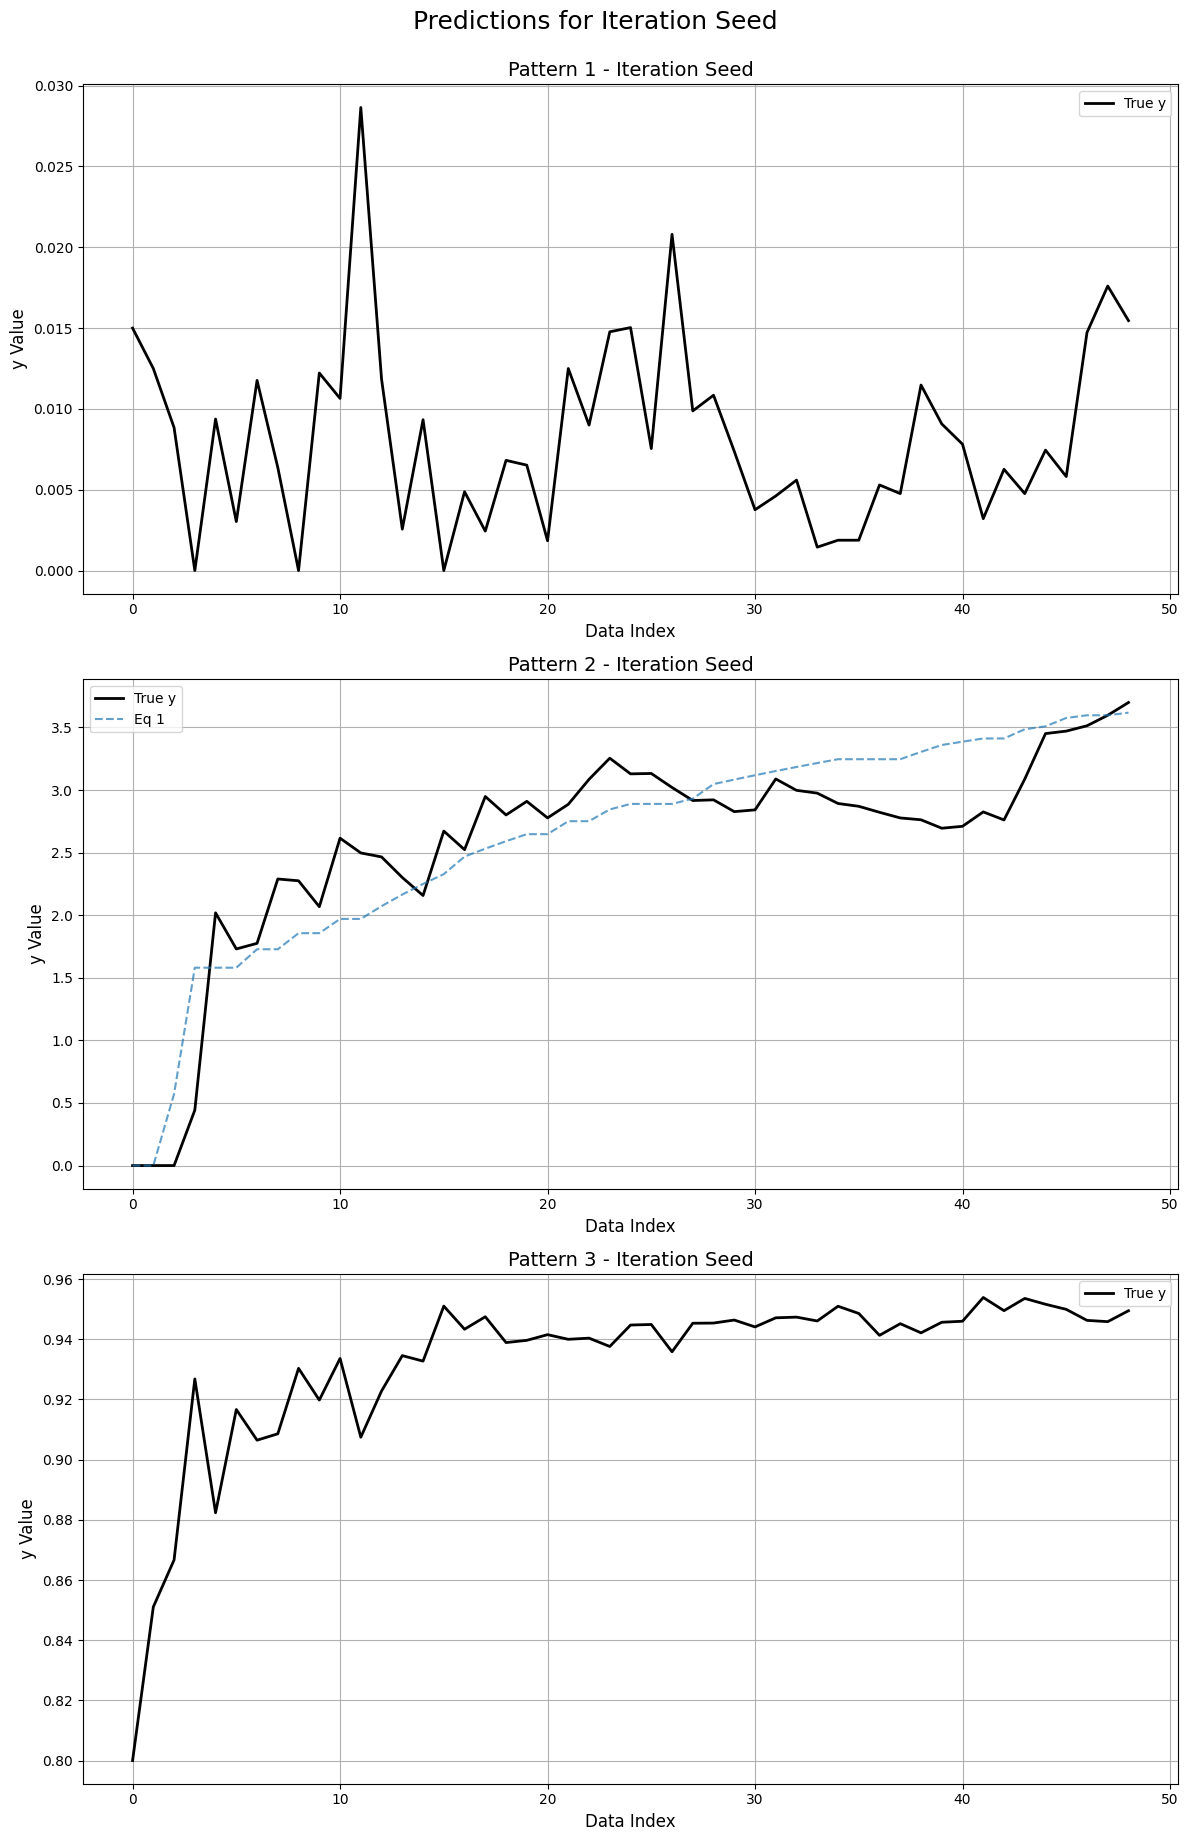

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad Analysis:
For Pattern 1 (predicting next-slot average compute load), I incorporated a mix of polynomial, logarithmic, square-root, and exponential terms with all six independent variables (x₁: task success ratio, x₂: vehicle density, x₃: UAV density, x₄, x₅, x₆: junction vehicle counts). The expressions use basic operations (addition, subtraction, multiplication, division) along with allowed unary functions “square”, “cube”, “sqrt”, “log”, and “exp”. One of the expressions also uses a moving average on one of the junction counts.
For Pattern 2 (predicting next-slot average V2U rate) only three inputs (x₁: vehicle density, x₂: UAV density, x₃: current compute load) are used. The expressions are constructed with square-root, logarithmic, exponential and polynomial structures in order to capture subtle non-linear effects as the communication rate is influenced by spatial vehicle/UAV patterns.
For Pattern

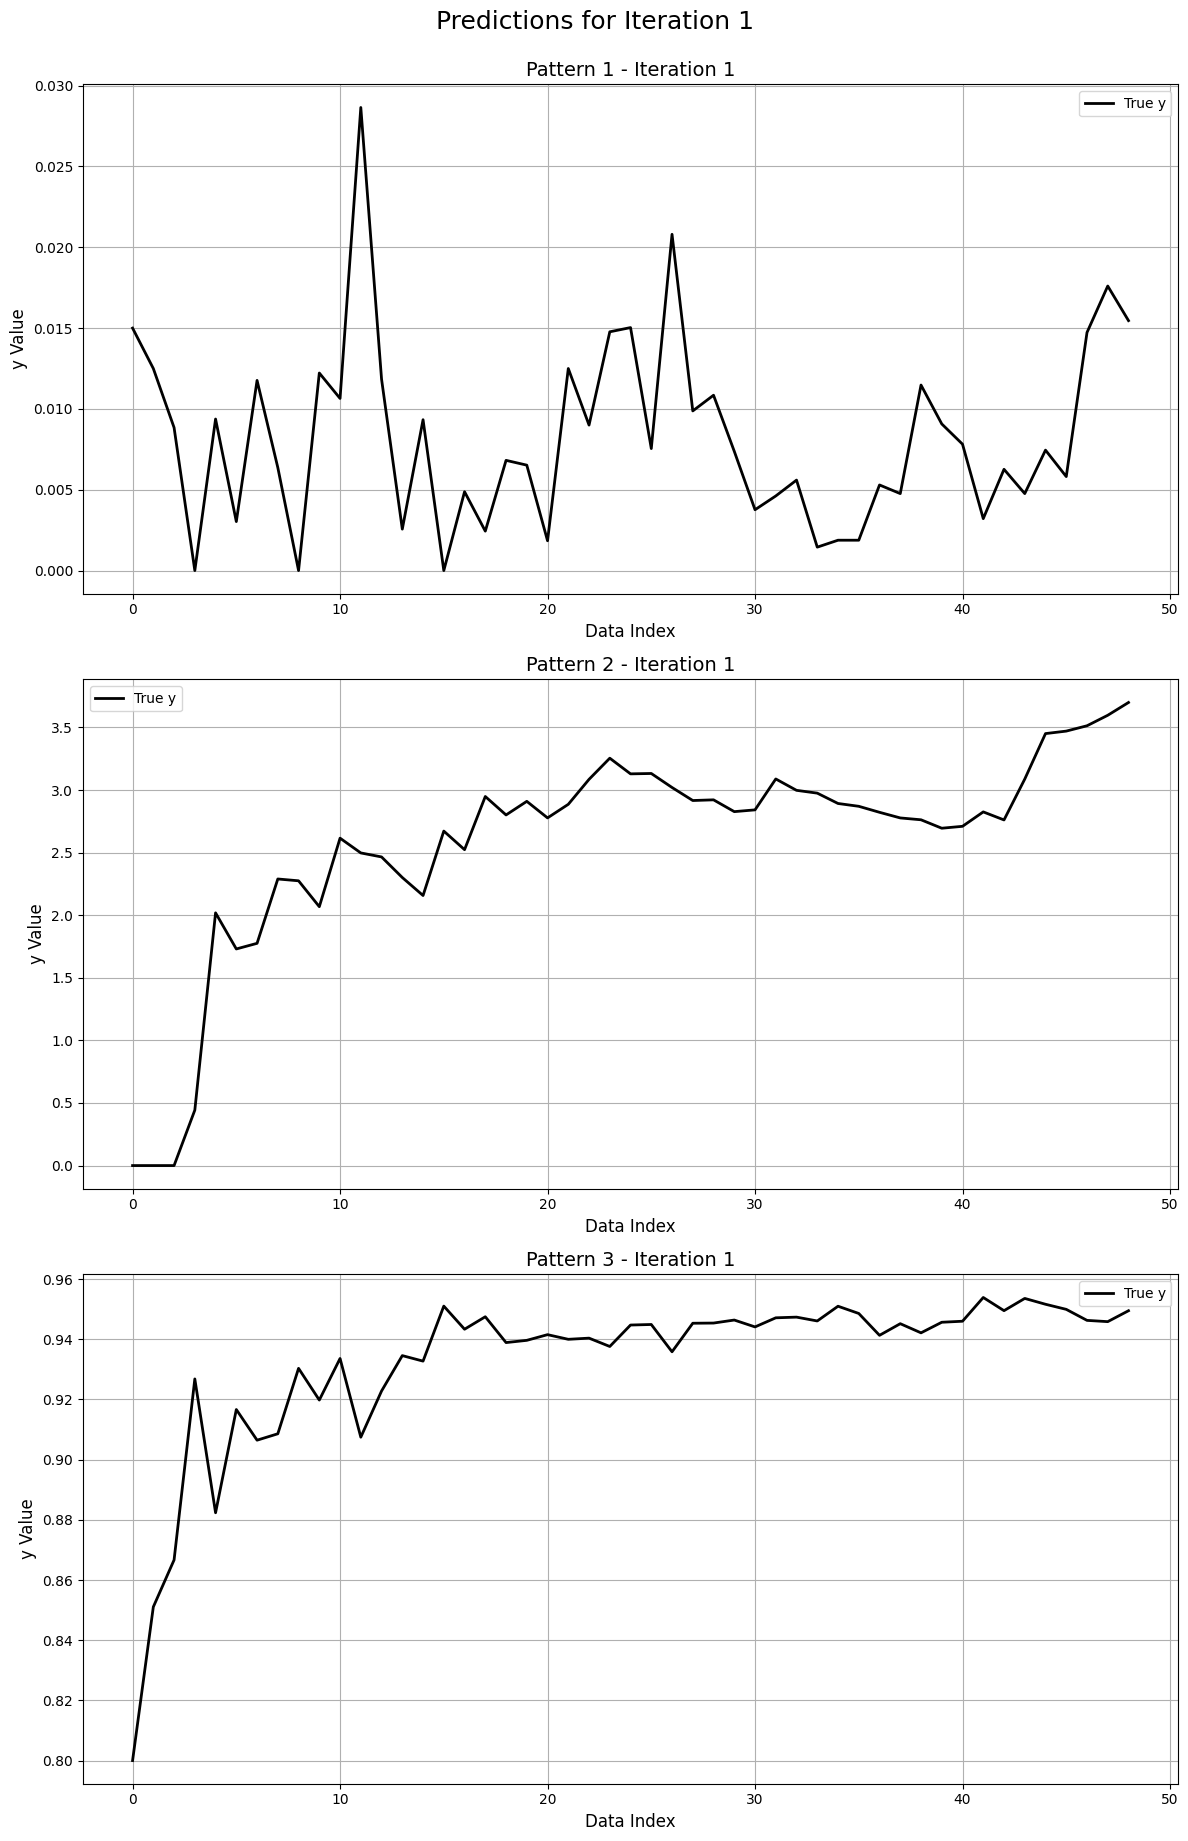

Iteration:1
SciPy feedback used for this iteration:
[[], [{'equation': 'c[0]+log(x1+c[1])+exp(-x2)*x3', 'complexity': 13, 'nmae': np.float64(0.08205410228799291), 'fitted_params': [1.679580173631178, -0.24517549990526405]}], []]
LLM thoughts:
Scratch Pad:
For Pattern 1 (next-slot average compute load), we target expressions that combine effects of the current task success ratio (x₁), vehicle density (x₂), UAV density (x₃) and counts from key junctions (x₄, x₅, x₆). We include logarithmic, exponential and square root terms to capture oscillatory and non‐linear behavior. The first expression uses log on x₁ and an exponential decay on x₂ multiplied by a sum of x₃ and x₄. The second expression blends a multiplicative interaction of x₁ and x₂ with a square root offset on x₅ and a division involving x₃ and x₆. The third expression sums a log of the total junction counts with a fraction of the product x₁*x₂ over (x₃ + constant).

For Pattern 2 (next-slot average V2U rate), given the influence

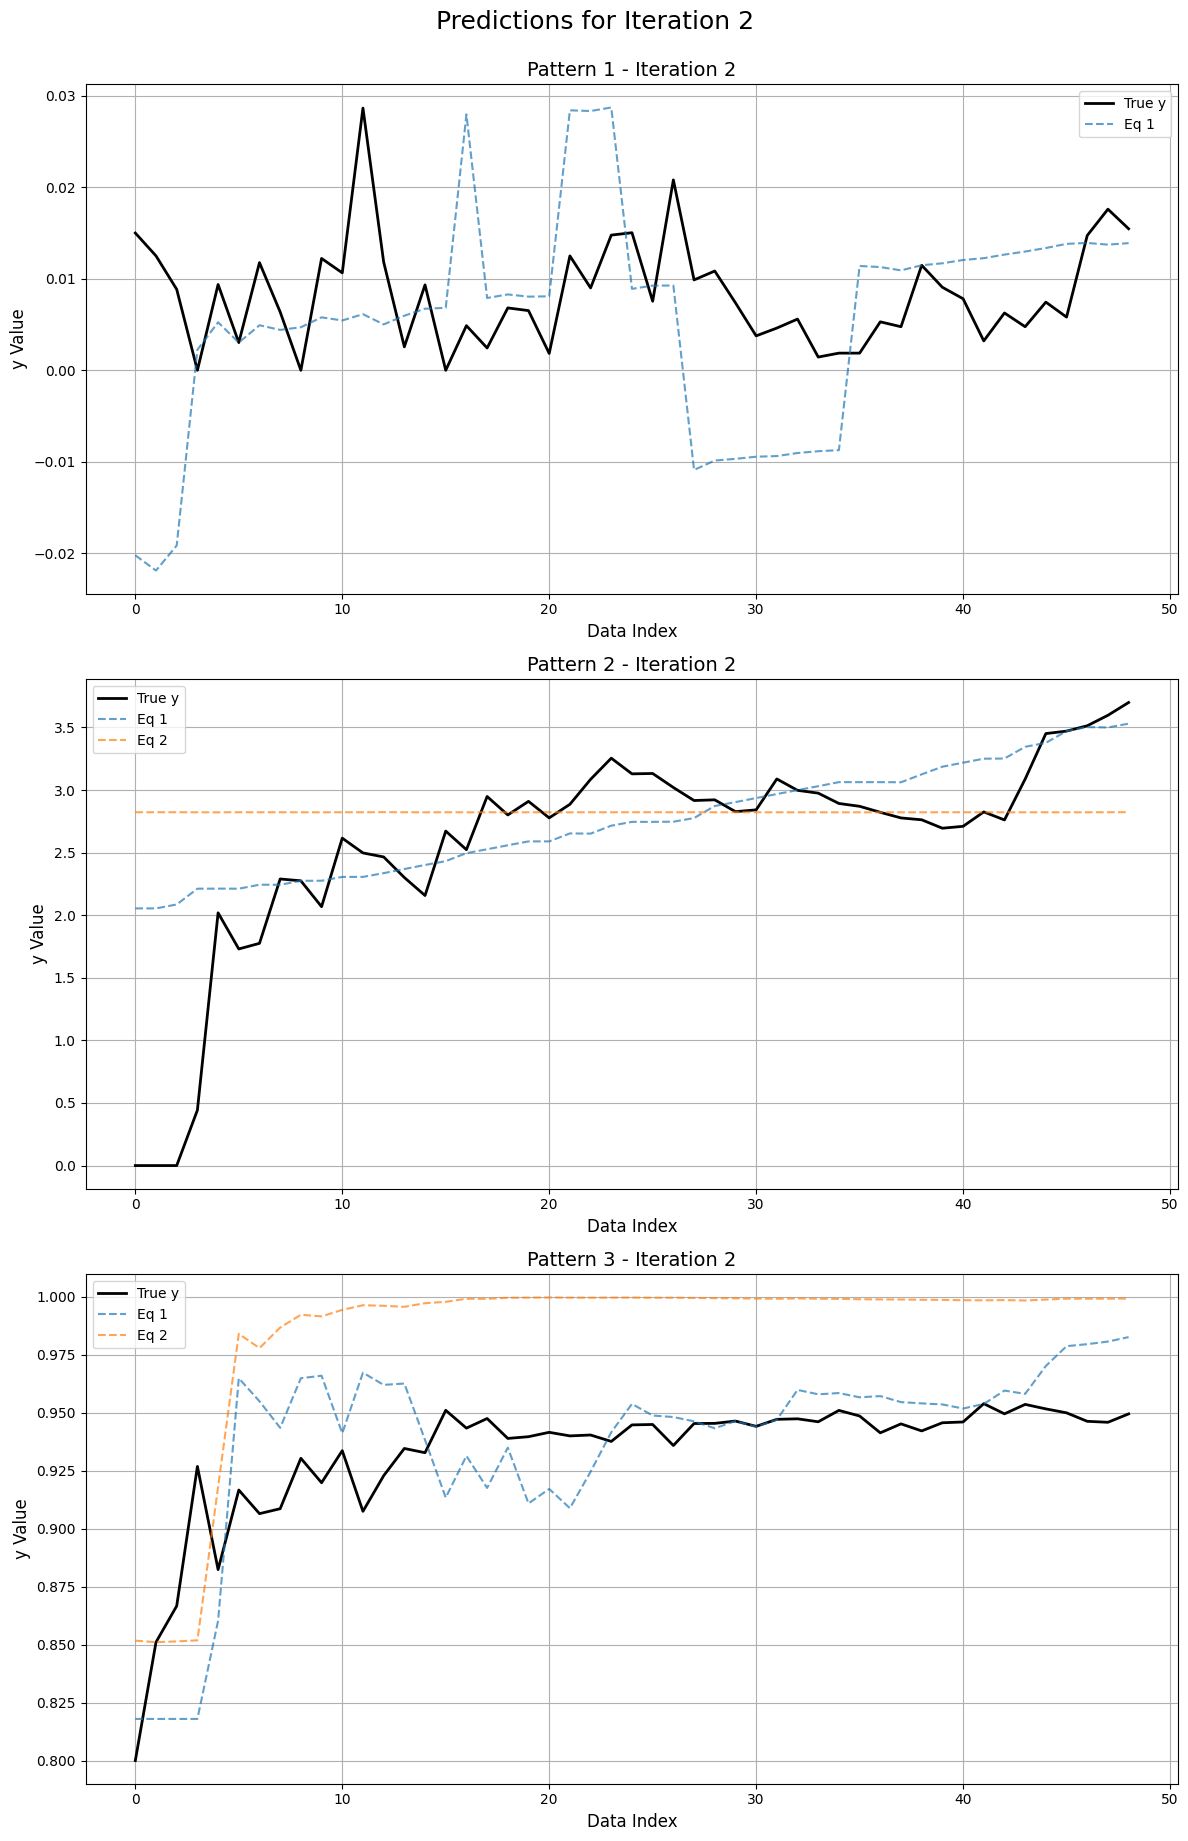

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(x1+c[1])+(x2)/(x3+c[2])+(x4+c[3])**0.5', 'complexity': 18, 'nmae': np.float64(0.3355961162501848), 'fitted_params': [-28.164307745401523, 19.169918094182876, 777.41622079833, 632.4044987151929]}], [{'equation': 'c[0]+log(x1+c[1])+exp(-x2)*x3', 'complexity': 13, 'nmae': np.float64(0.08205410228799291), 'fitted_params': [1.679580173631178, -0.24517549990526405]}, {'equation': 'c[0]+log(x2+c[1])+(x1)/(x3+c[2])', 'complexity': 12, 'nmae': np.float64(0.10098056479239476), 'fitted_params': [0.19055343863549562, -1.325213919926096, 4.564172924671236]}, {'equation': 'c[0]+(x2)/(x1+c[1])+(x3+c[2])**0.5', 'complexity': 13, 'nmae': np.float64(0.13915206465643457), 'fitted_params': [-8.176835117034333, 1092.0994463896309, 120.83061750405582]}], [{'equation': '1/(1+exp(-(c[0]+x1-(x2)/(x3+c[1]))))', 'complexity': 16, 'nmae': np.float64(0.139641186639486), 'fitted_params': [1.5025450565602236, 1.686662729042642]}, {'equation

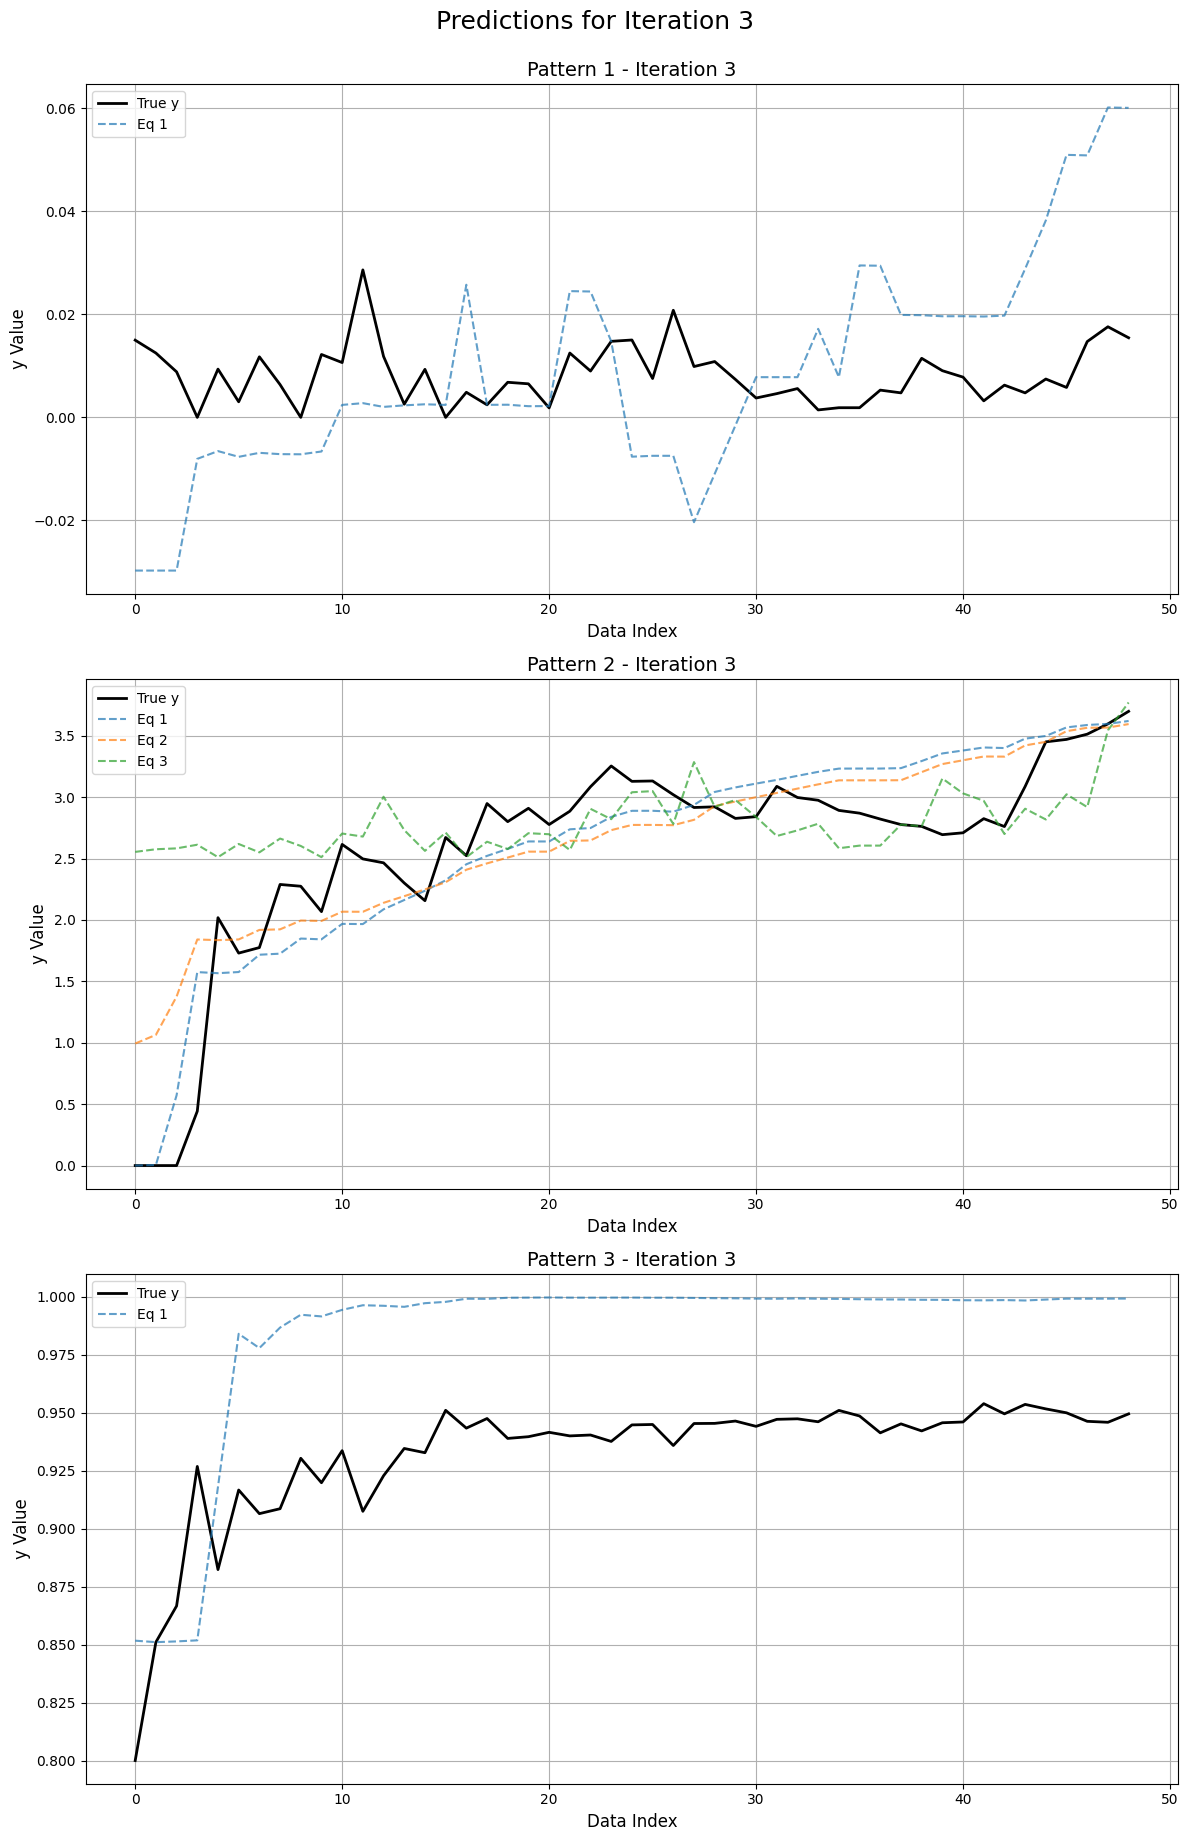

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(x1+c[1])+(x2)/(x3+c[2])+(x4+c[3])**0.5', 'complexity': 18, 'nmae': np.float64(0.3355961162501848), 'fitted_params': [-28.164307745401523, 19.169918094182876, 777.41622079833, 632.4044987151929]}, {'equation': 'c[0]+(x1*x4)/(x2+c[1])+(x3+x5+c[2])**0.5+log(x6+c[3])', 'complexity': 22, 'nmae': np.float64(0.5972362288258068), 'fitted_params': [-59.57562490709666, 38.78873625740762, 2825.4724992060183, 557.2833246247603]}], [{'equation': 'c[0]+(x1*x3)/(x2+c[1])+(x2+c[2])**0.5', 'complexity': 15, 'nmae': np.float64(0.12235447091698881), 'fitted_params': [-1.303572836382353, -7.0932487107467175, 7.363156524472382]}, {'equation': 'c[0]+log(x2+c[1])+(x1)/(x3+c[2])', 'complexity': 12, 'nmae': np.float64(0.10098056479239476), 'fitted_params': [0.19055343863549562, -1.325213919926096, 4.564172924671236]}, {'equation': 'c[0]+log(x1+c[1])+exp(-x2)*x3', 'complexity': 13, 'nmae': np.float64(0.08205410228799291), 'fitted_param

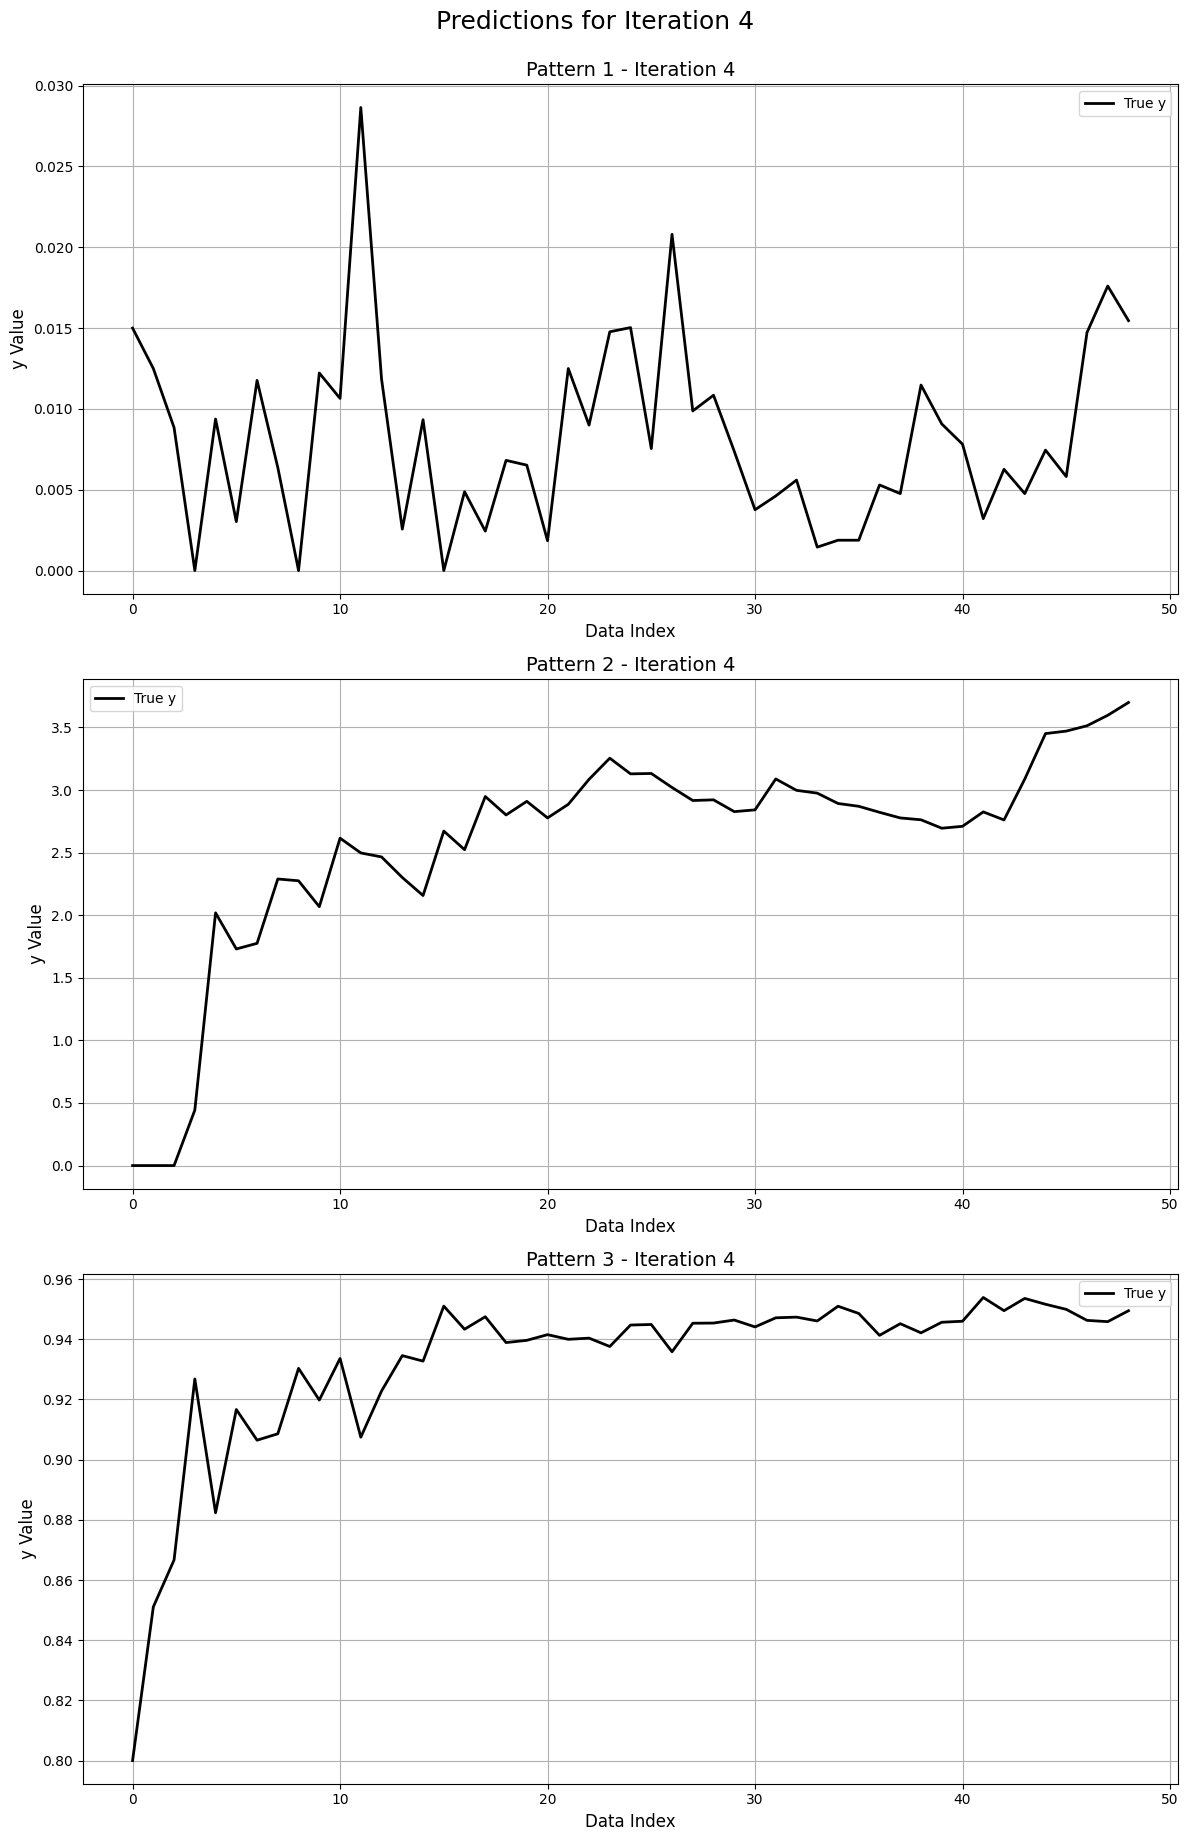

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(x1+c[1])+(x2)/(x3+c[2])+(x4+c[3])**0.5', 'complexity': 18, 'nmae': np.float64(0.3355961162501848), 'fitted_params': [-28.164307745401523, 19.169918094182876, 777.41622079833, 632.4044987151929]}, {'equation': 'c[0]+(x1*x4)/(x2+c[1])+(x3+x5+c[2])**0.5+log(x6+c[3])', 'complexity': 22, 'nmae': np.float64(0.5972362288258068), 'fitted_params': [-59.57562490709666, 38.78873625740762, 2825.4724992060183, 557.2833246247603]}], [{'equation': 'c[0]+(x1*x3)/(x2+c[1])+(x2+c[2])**0.5', 'complexity': 15, 'nmae': np.float64(0.12235447091698881), 'fitted_params': [-1.303572836382353, -7.0932487107467175, 7.363156524472382]}, {'equation': 'c[0]+log(x2+c[1])+(x1)/(x3+c[2])', 'complexity': 12, 'nmae': np.float64(0.10098056479239476), 'fitted_params': [0.19055343863549562, -1.325213919926096, 4.564172924671236]}, {'equation': 'c[0]+log(x1+c[1])+exp(-x2)*x3', 'complexity': 13, 'nmae': np.float64(0.08205410228799291), 'fitted_param

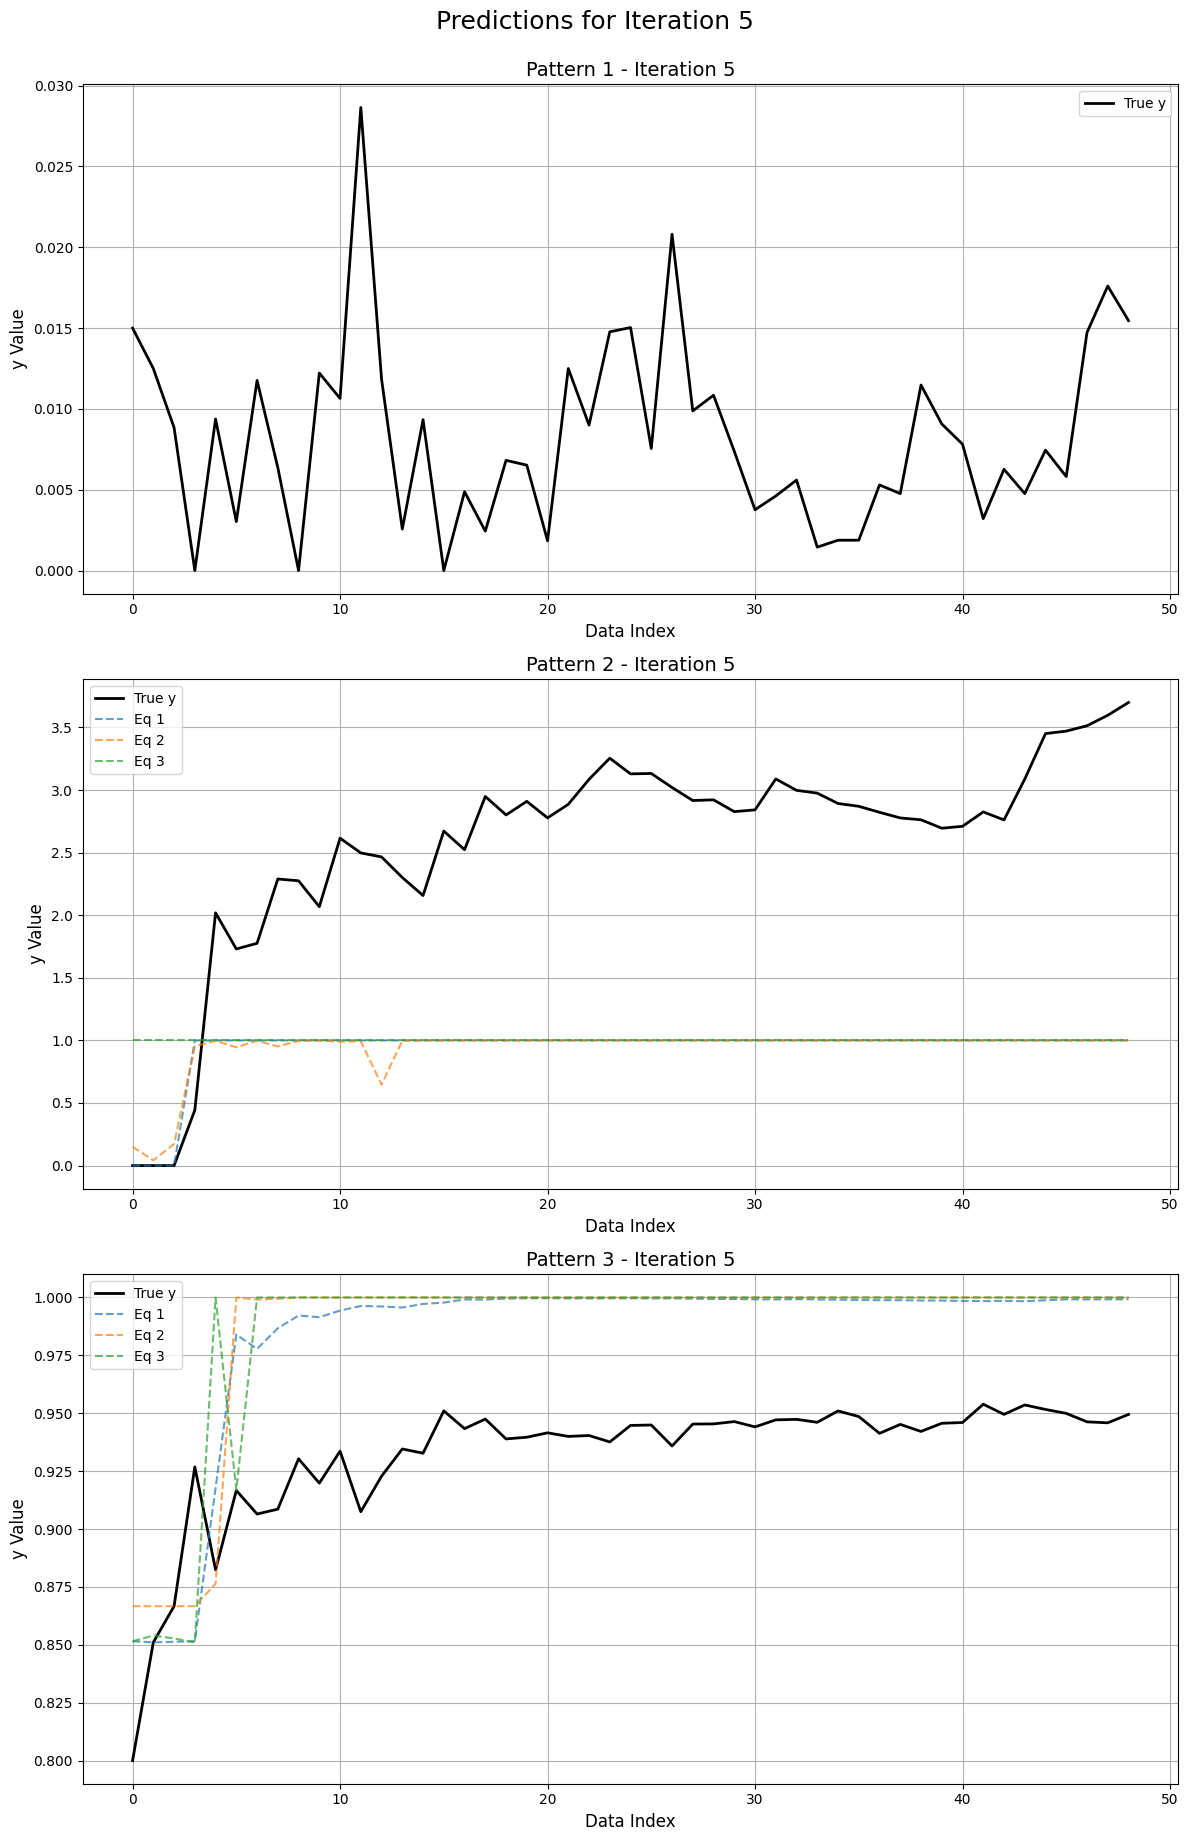

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(x1+c[1])+(x2)/(x3+c[2])+(x4+c[3])**0.5', 'complexity': 18, 'nmae': np.float64(0.3355961162501848), 'fitted_params': [-28.164307745401523, 19.169918094182876, 777.41622079833, 632.4044987151929]}, {'equation': 'c[0]+(x1*x4)/(x2+c[1])+(x3+x5+c[2])**0.5+log(x6+c[3])', 'complexity': 22, 'nmae': np.float64(0.5972362288258068), 'fitted_params': [-59.57562490709666, 38.78873625740762, 2825.4724992060183, 557.2833246247603]}], [{'equation': '1/(1+exp(-(c[0]+x1/(x2+c[1])-x3)))', 'complexity': 16, 'nmae': np.float64(0.44902238959029317), 'fitted_params': [-111.80914720167362, -7.186436408006838]}, {'equation': 'c[0]+(x1*x3)/(x2+c[1])+(x2+c[2])**0.5', 'complexity': 15, 'nmae': np.float64(0.12235447091698881), 'fitted_params': [-1.303572836382353, -7.0932487107467175, 7.363156524472382]}, {'equation': 'c[0]+log(x2+c[1])+(x1)/(x3+c[2])', 'complexity': 12, 'nmae': np.float64(0.10098056479239476), 'fitted_params': [0.1905534

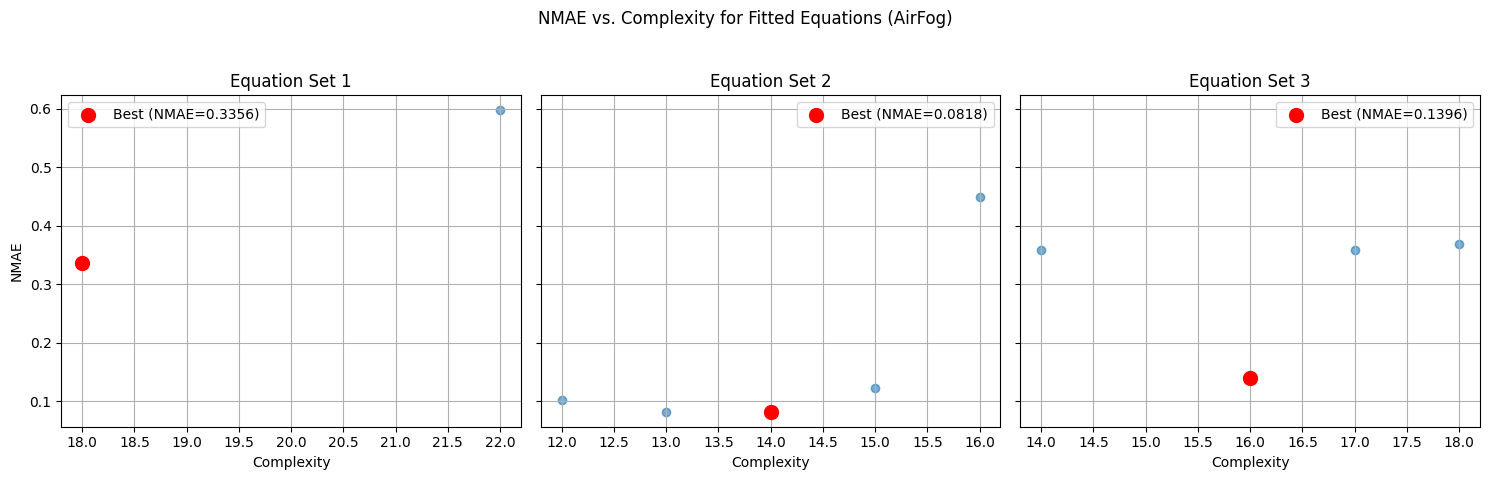

Experiment 1 finished.
Running experiment 2...
Invalid equation: c[0]+c[1]*movavg(x1,c[2])+c[3]*x2**2+c[4]*sqrt(x4+x5+x6). Error: arrays used as indices must be of integer (or boolean) type


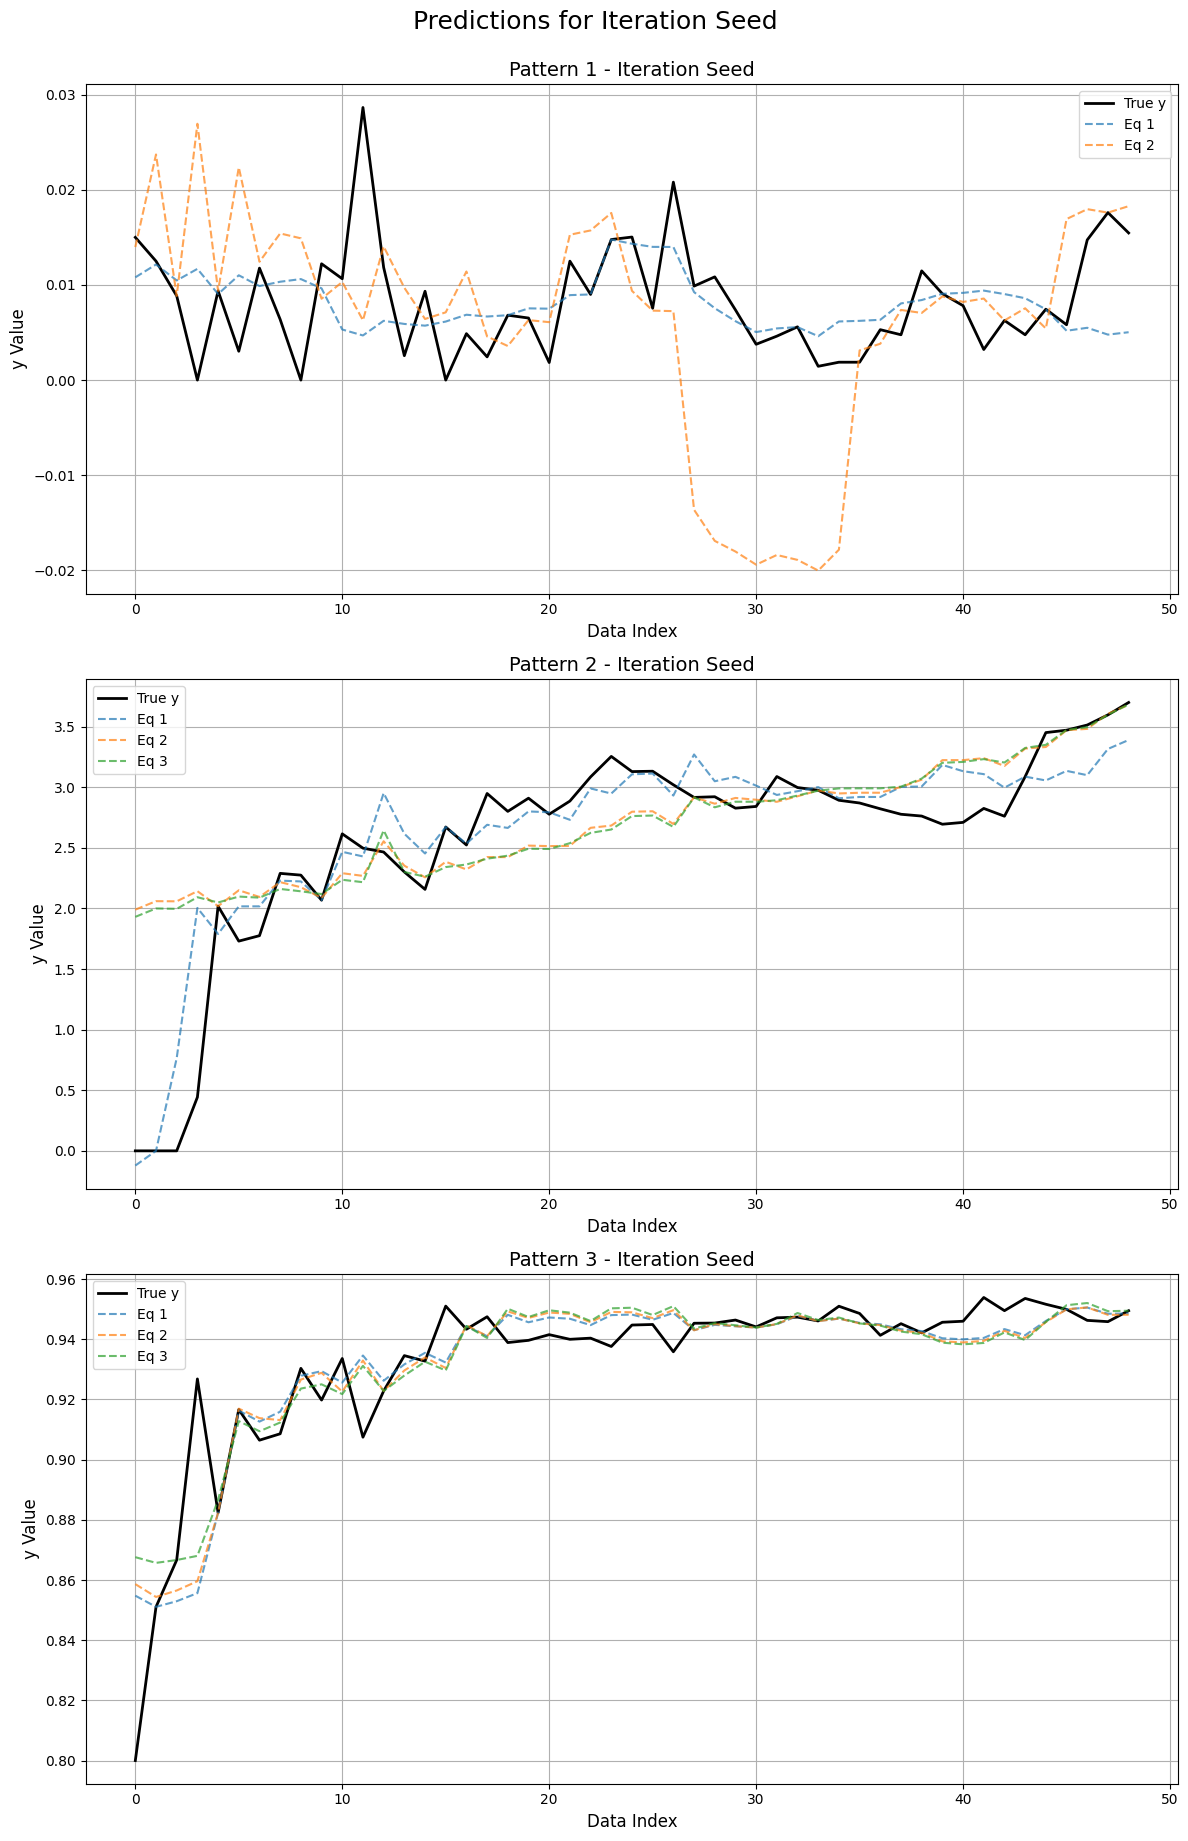

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:
For Pattern 1 we use the 6 independent variables (x₁: task success ratio, x₂: vehicle density, x₃: UAV density, x₄, x₅, x₆: junction counts). We incorporate non‐linearities with square, sqrt, exp and log functions. The first candidate is a mix of linear, squared and square-rooted terms. The second uses an exponential of x₁, a logged version of x₂ and a squared term on x₄ plus a square-root of the sum of x₅ and x₆. The third candidate introduces a moving average on x₁ (using movavg) together with squared and composite square-root components.

For Pattern 2 we have three independent variables (x₁: vehicle density, x₂: UAV density, x₃: compute load) and we shape the non‐linear response by including divisions (e.g. x₂ divided by (c₃+x₁)), square-root and logarithmic transformations and a squared term of x₃.

For Pattern 3 the dependent variable (task success ratio) must be bounded in [0,1]. Hence we use 

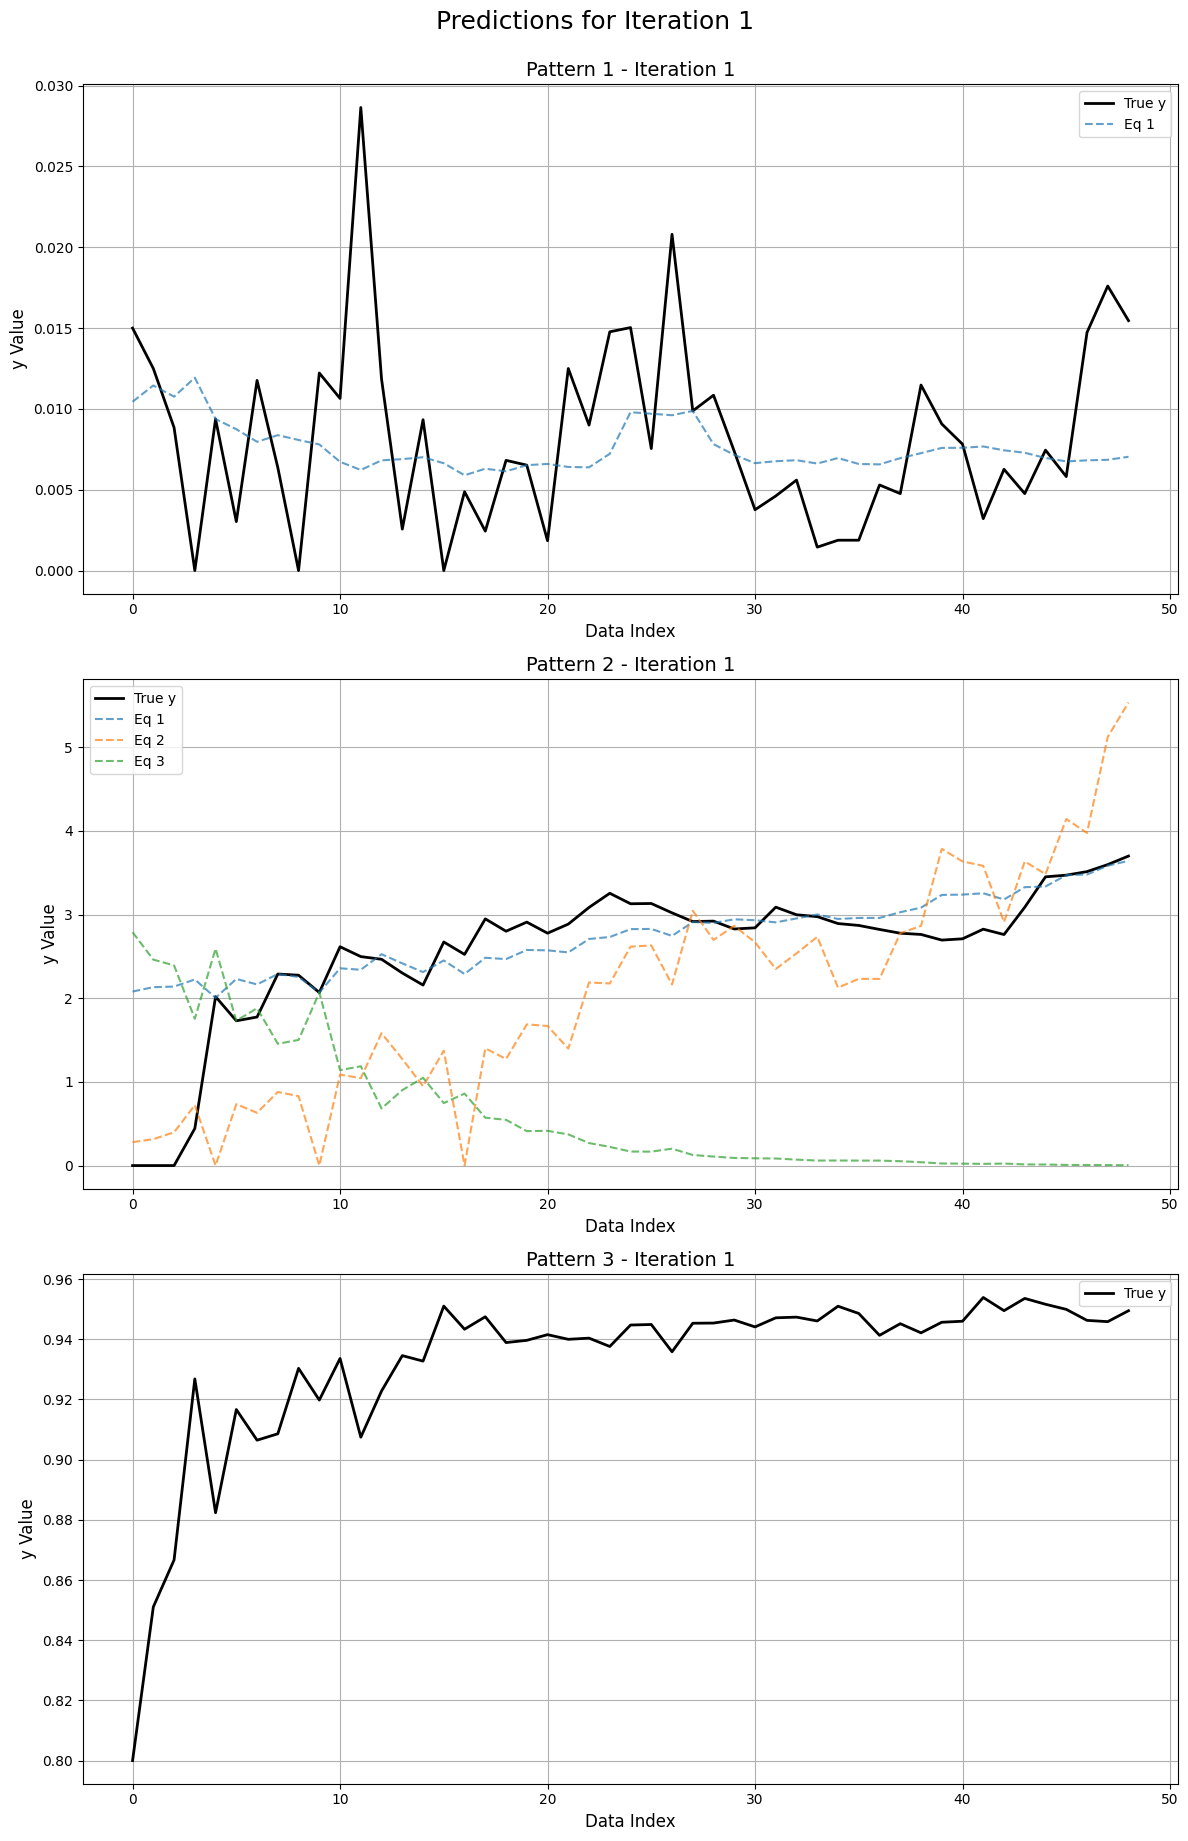

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*exp(x1)+c[1]*log(x2+c[2])+c[3]*x4**2+c[4]*sqrt(x5+x6)', 'complexity': 24, 'nmae': np.float64(0.1406167128037047), 'fitted_params': [-0.0179247033483474, 0.024398881456998898, 8.008018480510131, 0.0002919826192545616, -0.005168268900849711]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3+c[4]*sqrt(x4)+c[5]*x5+c[6]*x6', 'complexity': 28, 'nmae': np.float64(0.2872320552259693), 'fitted_params': [157.69157517435832, -0.2919189299588395, 0.0002715089628046363, -21.88481093156571, 0.02237597699698054, -0.001431964778340403, 0.005397467612023466]}, {'equation': 'c[0]*movavg(1, 3)+(c[1]*x2)/(1+log(x4+x5+x6))-c[2]*sqrt(x3)', 'complexity': 21, 'nmae': np.float64(0.14518366624967896), 'fitted_params': [-0.0604594686532821, 0.0016019485810132251, -0.022678799158221165]}], [{'equation': '(c[0]*x2+c[1]*sqrt(x3))/(1+exp(x1))', 'complexity': 13, 'nmae': np.float64(0.6286984947232187), 'fitted_params': [1.4993872495418417, -37.030

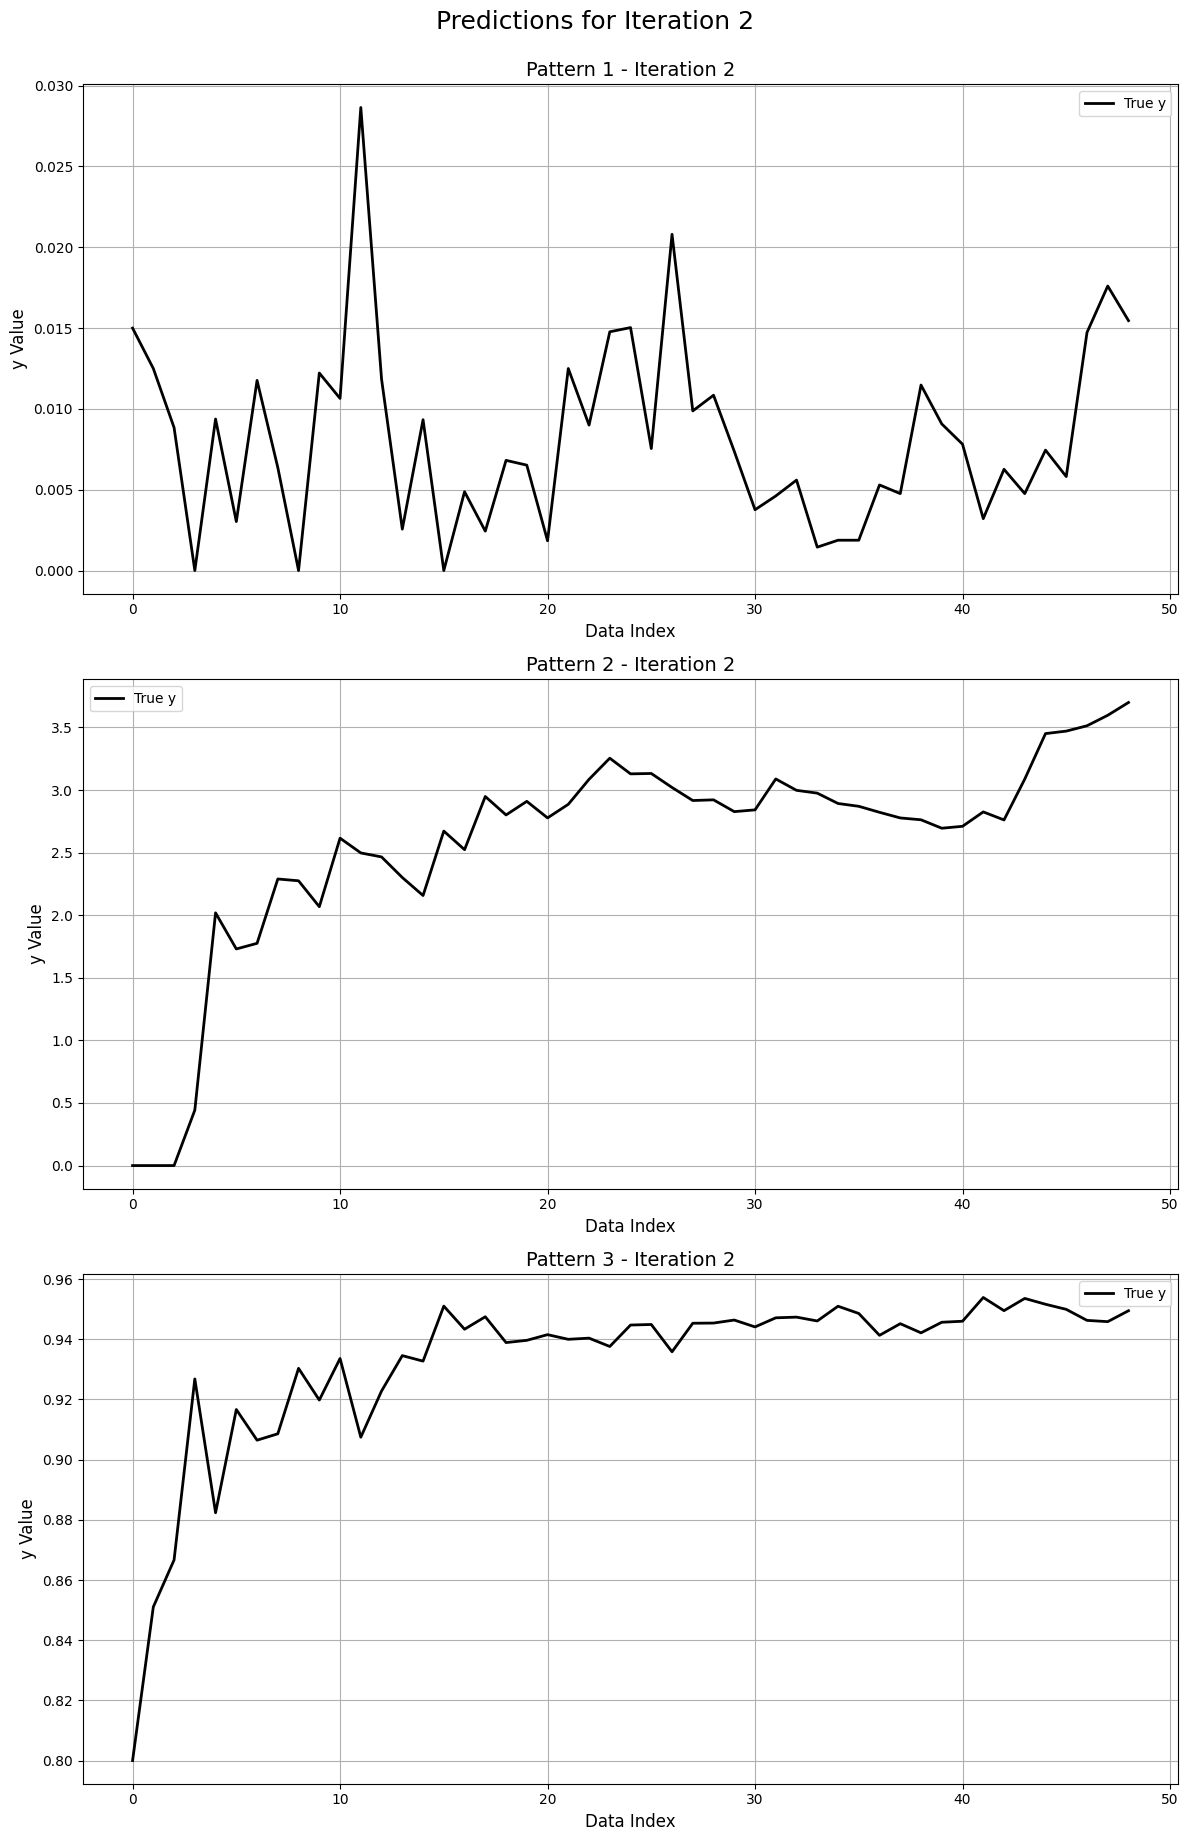

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*exp(x1)+c[1]*log(x2+c[2])+c[3]*x4**2+c[4]*sqrt(x5+x6)', 'complexity': 24, 'nmae': np.float64(0.1406167128037047), 'fitted_params': [-0.0179247033483474, 0.024398881456998898, 8.008018480510131, 0.0002919826192545616, -0.005168268900849711]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3+c[4]*sqrt(x4)+c[5]*x5+c[6]*x6', 'complexity': 28, 'nmae': np.float64(0.2872320552259693), 'fitted_params': [157.69157517435832, -0.2919189299588395, 0.0002715089628046363, -21.88481093156571, 0.02237597699698054, -0.001431964778340403, 0.005397467612023466]}, {'equation': 'c[0]*movavg(1, 3)+(c[1]*x2)/(1+log(x4+x5+x6))-c[2]*sqrt(x3)', 'complexity': 21, 'nmae': np.float64(0.14518366624967896), 'fitted_params': [-0.0604594686532821, 0.0016019485810132251, -0.022678799158221165]}], [{'equation': '(c[0]*x2+c[1]*sqrt(x3))/(1+exp(x1))', 'complexity': 13, 'nmae': np.float64(0.6286984947232187), 'fitted_params': [1.4993872495418417, -37.030

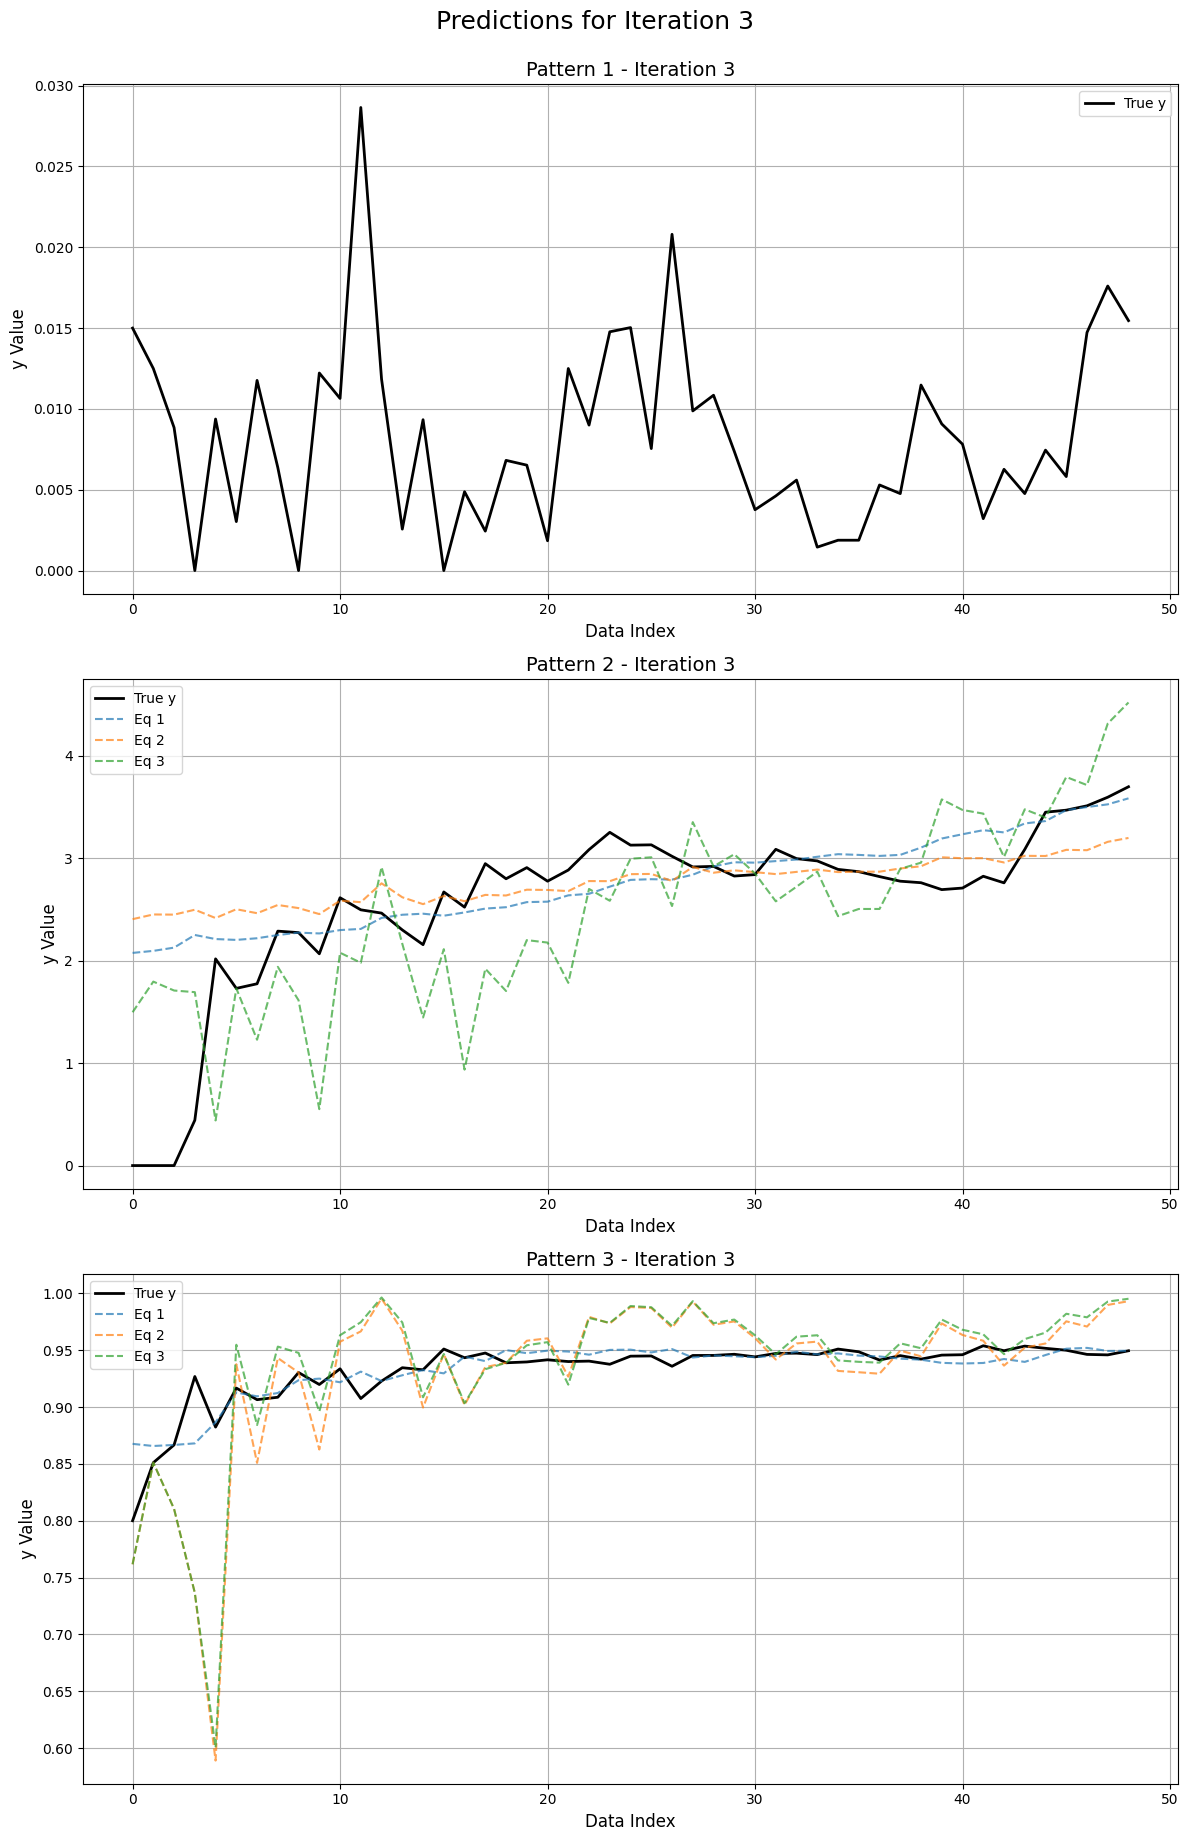

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*exp(x1)+c[1]*log(x2+c[2])+c[3]*x4**2+c[4]*sqrt(x5+x6)', 'complexity': 24, 'nmae': np.float64(0.1406167128037047), 'fitted_params': [-0.0179247033483474, 0.024398881456998898, 8.008018480510131, 0.0002919826192545616, -0.005168268900849711]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3+c[4]*sqrt(x4)+c[5]*x5+c[6]*x6', 'complexity': 28, 'nmae': np.float64(0.2872320552259693), 'fitted_params': [157.69157517435832, -0.2919189299588395, 0.0002715089628046363, -21.88481093156571, 0.02237597699698054, -0.001431964778340403, 0.005397467612023466]}, {'equation': 'c[0]*movavg(1, 3)+(c[1]*x2)/(1+log(x4+x5+x6))-c[2]*sqrt(x3)', 'complexity': 21, 'nmae': np.float64(0.14518366624967896), 'fitted_params': [-0.0604594686532821, 0.0016019485810132251, -0.022678799158221165]}], [{'equation': '(c[0]*x2+c[1]*sqrt(x3))/(1+exp(x1))', 'complexity': 13, 'nmae': np.float64(0.6286984947232187), 'fitted_params': [1.4993872495418417, -37.030

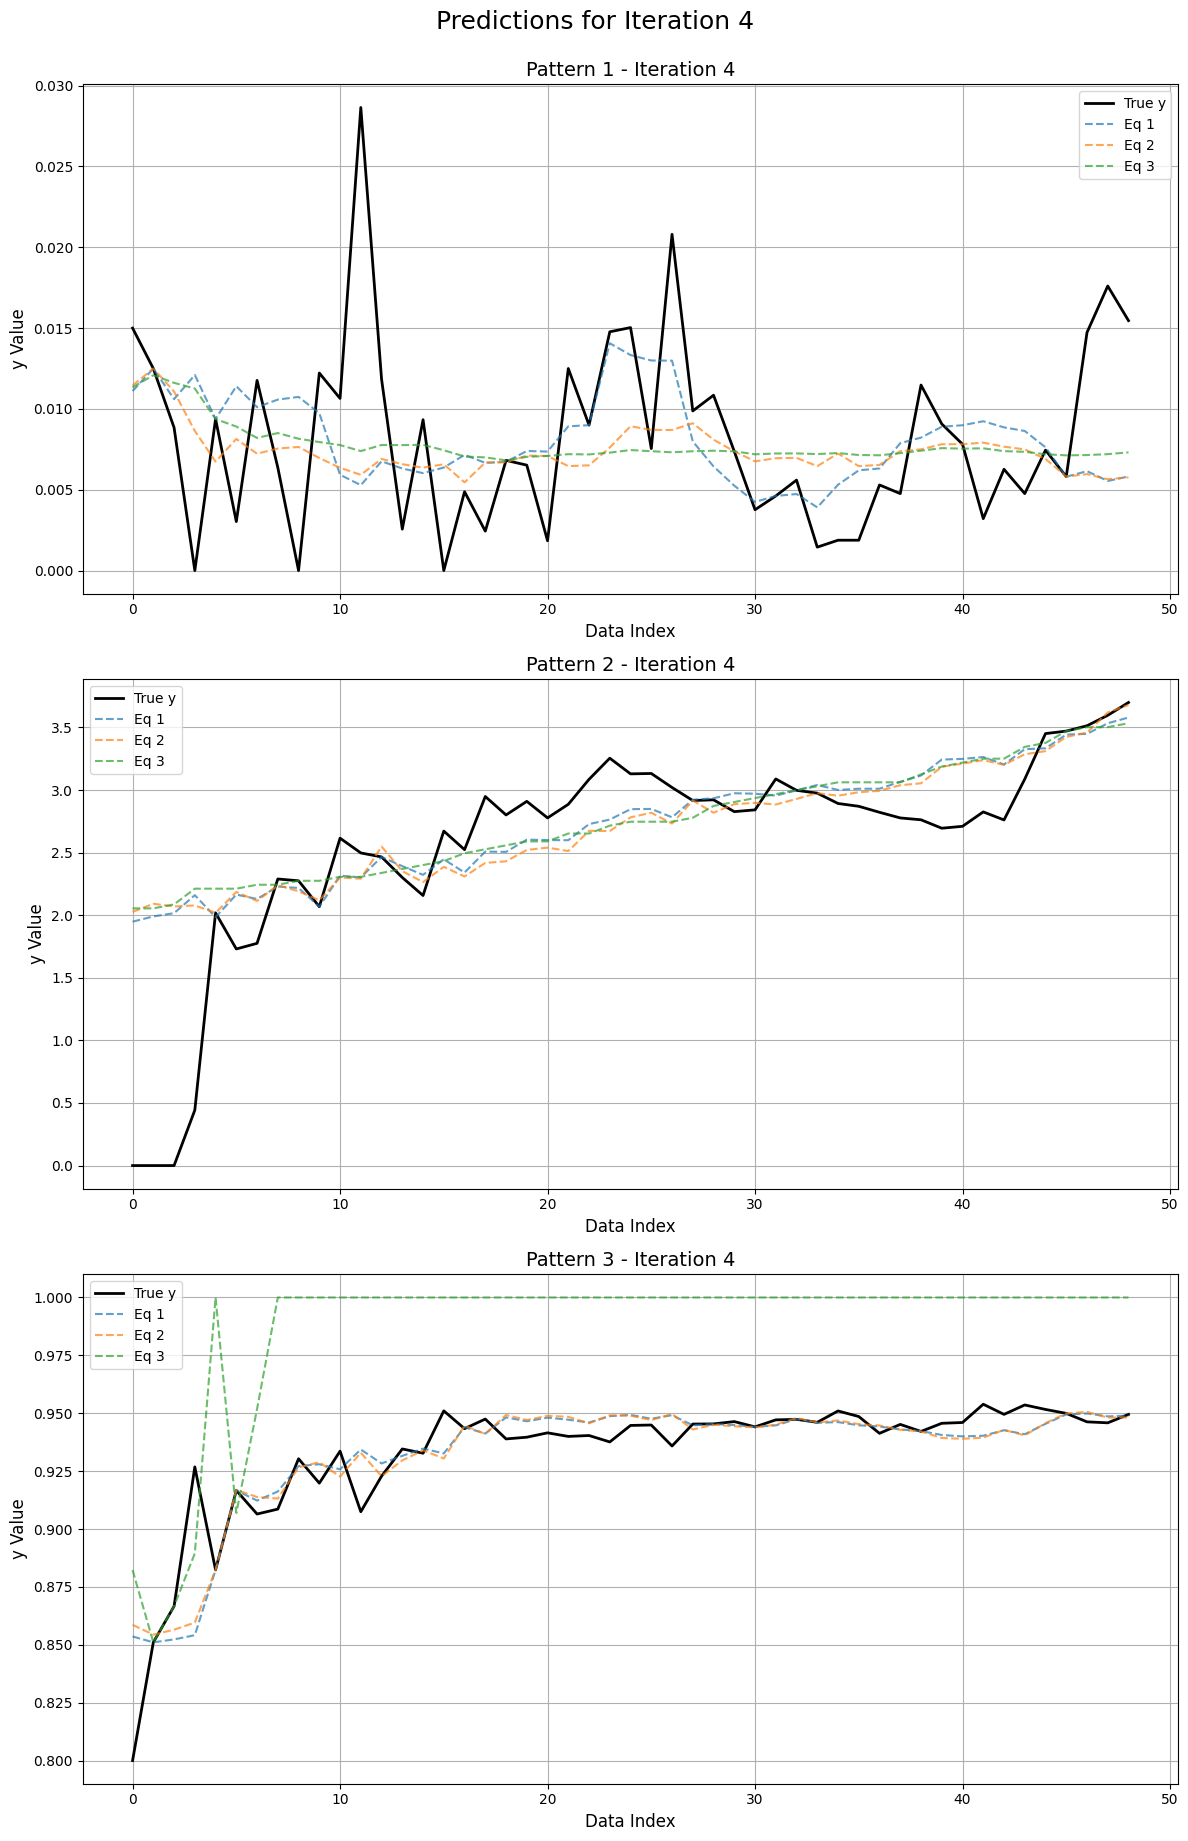

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3+c[4]*sqrt(x4)+c[5]*x5+c[6]*x6', 'complexity': 28, 'nmae': np.float64(0.2872320552259693), 'fitted_params': [157.69157517435832, -0.2919189299588395, 0.0002715089628046363, -21.88481093156571, 0.02237597699698054, -0.001431964778340403, 0.005397467612023466]}, {'equation': 'c[0]+c[1]*movavg(1, 3)+c[2]*(x2*x3)/(x4+x5+x6+c[3])', 'complexity': 19, 'nmae': np.float64(0.14875135119266755), 'fitted_params': [0.04840558308317157, -0.04462886594577156, 0.0005302885525910899, 13.132304600043089]}, {'equation': 'c[0]*movavg(1, 3)+(c[1]*x2)/(1+log(x4+x5+x6))-c[2]*sqrt(x3)', 'complexity': 21, 'nmae': np.float64(0.14518366624967896), 'fitted_params': [-0.0604594686532821, 0.0016019485810132251, -0.022678799158221165]}, {'equation': 'c[0]*exp(x1)+c[1]*log(x2+c[2])+c[3]*x4**2+c[4]*sqrt(x5+x6)', 'complexity': 24, 'nmae': np.float64(0.1406167128037047), 'fitted_params': [-0.0179247033483474, 0.02439888145

ValueError: Unsupported expression format

In [ ]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_align_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


Parsed Row:
['c[0] \\cdot x1^2 + c[1] \\cdot movavg(x2, 3) + c[2] \\cdot log(x4 + x5)', 'c[0] \\cdot x1 \\cdot x2 + c[1] \\cdot x3^2 + c[2] \\cdot sqrt(x6)', 'c[0] \\cdot log(x1 + x2) + c[1] \\cdot movavg(x5, 2) + c[2] \\cdot x4 \\cdot x6']
Formatted Row:
['c[0]*x1**2+c[1]*movavg(2, 3)+c[2]*log(x4+x5)', 'c[0]*x1*x2+c[1]*x3**2+c[2]*sqrt(x6)', 'c[0]*log(x1+x2)+c[1]*movavg(5, 2)+c[2]*x4*x6']


Parsed Row:
['c[0] \\cdot x1 \\cdot x3 + c[1] \\cdot sqrt(x2)', 'c[0] \\cdot x1^2 + c[1] \\cdot x3^2 + c[2] \\cdot movavg(x1, 4)', 'c[0] \\cdot log(x1) + c[1] \\cdot x2 \\cdot x3']
Formatted Row:
['c[0]*x1*x3+c[1]*sqrt(x2)', 'c[0]*x1**2+c[1]*x3**2+c[2]*movavg(1, 4)', 'c[0]*log(x1)+c[1]*x2*x3']


Parsed Row:
['(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot x2 + c[2] \\cdot x3)))', '\\min(1, \\max(0, c[0] \\cdot x1^2 + c[1] \\cdot x2 + c[2] \\cdot \\log(x3)))', '(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot \\sqrt{x2) + c[2] \\cdot x3))).']
Formatted Row:
['(1)/(1+exp(-(c[0]*x1+c[1]*x2+c[2]*x3)))',